# 04. The French OAT-Bund spread: fundamentals or political uncertainty?

**Question.** How much of the French 10-year spread over Germany can be tied to fiscal fundamentals (debt), and how much to political uncertainty and global risk appetite? And how did the market react on political dates?

Three tools, each with its own limits.
1. *ARDL / unconditional ECM with a bounds test* (Pesaran-Shin-Smith) on monthly data: is there a long-run relation between the spread, debt, uncertainty, risk appetite and Italian stress?
2. *Event study* on daily data: how unusual was the two-day spread move on political dates, compared with the previous year of daily moves?
3. *Local projections*: dynamic response of the spread to an uncertainty innovation.

Data (all public, downloaded by the code). French 10y: Banque de France TEC10. German 10y: Bundesbank Svensson zero-coupon 10y. Italy-Germany spread: ECB convergence-criterion yields. Debt/GDP: Eurostat quarterly (released with a 3-month lag, respected below). Political uncertainty: Baker-Bloom-Davis newspaper-based index for France. VIX: FRED.

**Limits.** The French (constant-maturity, from 11 a.m. prices) and German (Svensson zero-coupon) series are not the same instrument, so the level of the spread is approximate and one-day changes contain measurement noise; the event study uses two-day changes. The event list has six dates, so tests are suggestive only. Fiscal data stop in 2025.

In [1]:
import sys, warnings
sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ardl import UECM
import matplotlib.dates as mdates
from data_utils import fred, dbnomics, ecb, oat_bund_spread, DATA_DIR
from IPython.display import display
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})

## 1. Data
The daily spread comes from `oat_bund_spread()` in `src/data_utils.py`. It drops a day when the spread moves by more than 20 bp and at least three quarters of the move is undone the next day. One day meets the rule: on 28 June 2022 the French series gives 1.83%, against 2.18% in the Banque de France table of indicative OAT rates.

Daily: 2004-11-03 -> 2026-06-15 5483 obs | dropped as recording errors: ['2022-06-28']
Monthly panel: 2013-01-31 -> 2025-09-30 (153, 5)


,count,mean,std,min,25%,50%,75%,max
spread,153.0,41.4,14.6,17.5,29.7,37.9,53.1,75.9
debt,153.0,103.9,7.9,91.3,98.1,99.7,112.8,117.7
lepu,153.0,5.6,0.3,4.9,5.4,5.6,5.8,6.4
vix,153.0,17.7,6.2,10.1,13.7,15.9,19.8,57.7
it_spread,153.0,174.1,55.5,86.4,131.2,163.6,206.2,329.0


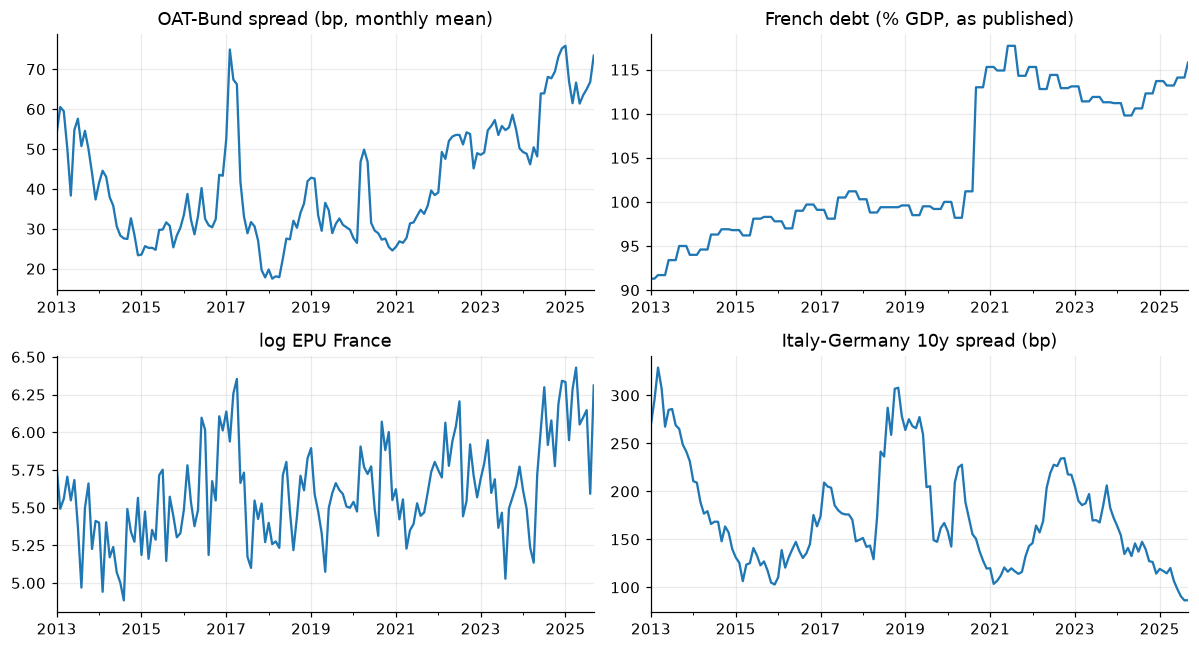

In [2]:
daily = oat_bund_spread()                                   # FR10, DE10 in %, spread in basis points
print("Daily:", daily.index[0].date(), "->", daily.index[-1].date(), len(daily), "obs | dropped as recording errors:", daily.attrs["dropped"])

it, de_m = ecb("IRS", "M.IT.L.L40.CI.0000.EUR.N.Z"), ecb("IRS", "M.DE.L.L40.CI.0000.EUR.N.Z")
it_sp = ((it - de_m) * 100).dropna(); it_sp.index = it_sp.index.to_period("M").to_timestamp("M")
debt = dbnomics("Eurostat", "gov_10q_ggdebt", "Q.GD.S13.PC_GDP.FR", "debt")
# quarter start -> quarter end -> +3 months publication lag
avail = (debt.index.to_period("Q").to_timestamp("Q") + pd.offsets.QuarterEnd(0)).to_period("M") + 3
debt_m = pd.Series(debt.values, index=avail.to_timestamp("M"), name="debt").resample("ME").last().ffill()
epu = pd.read_excel(DATA_DIR / "epu_europe.xlsx").dropna(subset=["Month"])
epu = epu[pd.to_numeric(epu.Year, errors="coerce").notna()]
epu.index = pd.to_datetime(dict(year=epu.Year.astype(int), month=epu.Month.astype(int), day=1)).dt.to_period("M").dt.to_timestamp("M")
vix = fred("VIXCLS").resample("ME").mean()

M = pd.concat([daily["spread"].resample("ME").mean().rename("spread"), debt_m, np.log(epu["France_News_Index"]).rename("lepu"),
               vix.rename("vix"), it_sp.rename("it_spread")], axis=1).loc["2013-01":"2025-09"].dropna()
print("Monthly panel:", M.index[0].date(), "->", M.index[-1].date(), M.shape)
display(M.describe().round(1).T)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
M.spread.plot(ax=axes[0, 0], title="OAT-Bund spread (bp, monthly mean)"); M.debt.plot(ax=axes[0, 1], title="French debt (% GDP, as published)")
M.lepu.plot(ax=axes[1, 0], title="log EPU France"); M.it_spread.plot(ax=axes[1, 1], title="Italy-Germany 10y spread (bp)")
for a in axes.ravel(): a.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/04_panel.png"); plt.show()

## 2. Unit roots
ADF rejects a unit root at low p-values; KPSS rejects stationarity at low p-values. If the two disagree, treat the series as persistent.

In [3]:
rows = []
for c in M.columns:
    for lab, s in [("level", M[c]), ("diff", M[c].diff().dropna())]:
        rows.append({"series": c, "form": lab, "ADF p": round(adfuller(s, regression="c", autolag="AIC")[1], 3), "KPSS p": round(kpss(s, regression="c", nlags="auto")[1], 3)})
ur = pd.DataFrame(rows).pivot(index="series", columns="form"); ur.to_csv("data/out_04_unit_roots.csv"); ur

ADF p        KPSS p       
form       diff  level   diff  level
series                              
debt        0.0  0.735    0.1  0.010
it_spread   0.0  0.025    0.1  0.100
lepu        0.0  0.230    0.1  0.010
spread      0.0  0.169    0.1  0.012
vix         0.0  0.000    0.1  0.036

## 3. ARDL / unconditional ECM and bounds test
Spread on debt, log uncertainty, VIX and the Italy-Germany spread. The bounds test asks whether the lagged levels are jointly significant. The long-run coefficient is -(coefficient on lagged level of x) / (coefficient on lagged spread).
Case 3 (unrestricted constant). Critical values for I(0) and I(1) bounds come from statsmodels.

In [4]:
exog = M[["debt", "lepu", "vix", "it_spread"]]
uecm = UECM(M["spread"], lags=2, exog=exog, order=1, trend="c")
res = uecm.fit(cov_type="HAC", cov_kwds={"maxlags": 4})
bt = res.bounds_test(case=3)
print(bt)
lr = {}
lag_y = [p for p in res.params.index if p.startswith("spread.L1")][0]
for x in exog.columns:
    px = [p for p in res.params.index if p.startswith(x + ".L1")][0]
    lr[x] = -res.params[px] / res.params[lag_y]
print("Adjustment coefficient on lagged spread (error correction speed):", round(res.params[lag_y], 3))
print("Implied long-run effects (bp of spread per unit of x):", {k: round(v, 2) for k, v in lr.items()})
if bt.p_values.iloc[1] > 0.10 if hasattr(bt.p_values, "iloc") else True:
    print("WARNING: the bounds test does not reject 'no cointegration' at 10%. The long-run coefficients above are shown for completeness and must NOT be read as a long-run relation.")
with open("data/out_04_uecm.txt", "w") as f:
    f.write(str(res.summary())); f.write("\n\nBounds test:\n" + str(bt))
res.params.round(3).to_frame("coef").assign(t=res.tvalues.round(2))

BoundsTestResult
Stat: 1.60451
Upper P-value: 0.717
Lower P-value: 0.304
Null: No Cointegration
Alternative: Possible Cointegration

Adjustment coefficient on lagged spread (error correction speed): -0.079
Implied long-run effects (bp of spread per unit of x): {'debt': np.float64(1.14), 'lepu': np.float64(22.59), 'vix': np.float64(-0.08), 'it_spread': np.float64(-0.0)}


,coef,t
const,-15.702,-1.94
spread.L1,-0.079,-2.03
debt.L1,0.090,1.82
lepu.L1,1.786,1.02
vix.L1,-0.006,-0.10
it_spread.L1,-0.000,-0.05
D.spread.L1,0.082,1.38
D.debt.L0,-0.066,-0.21
D.lepu.L0,3.162,2.78
D.vix.L0,0.217,2.97


## 4. Event study on political dates
Abnormal move = spread on the day after the event date minus spread on the day before it, a two-day change that contains the event date. Reference: the empirical distribution of all two-day changes in the 250 trading days that end 20 days before the event. We report the z-score and the empirical two-sided percentile. This avoids assuming normal returns, but with six events the test is only suggestive.

Event dates. News released over a weekend (the two first rounds, the dissolution) is dated on the Monday. The confidence vote announced on Monday 25 August 2025 in the afternoon, after the 11 a.m. French quote, is dated on the 26th. The two votes held in the evening (4 December 2024, 8 September 2025) are dated on the day of the vote. In every case the window starts before the news and ends after it.

,date,event,move_bp,z,two-sided empirical p
0,2017-04-24,1st round presidential (Macron v Le Pen),-16.8,-5.74,0.000
1,2024-06-10,Dissolution announced (Sun 9 June),15.0,8.82,0.000
2,2024-07-01,1st round legislative elections,-6.0,-3.54,0.008
3,2024-12-04,"Censure vote, Barnier government",-2.0,-0.85,0.376
4,2025-08-26,Bayrou announces confidence vote,9.0,3.39,0.012
5,2025-09-08,"Confidence vote, Bayrou government",-1.0,-0.38,0.568


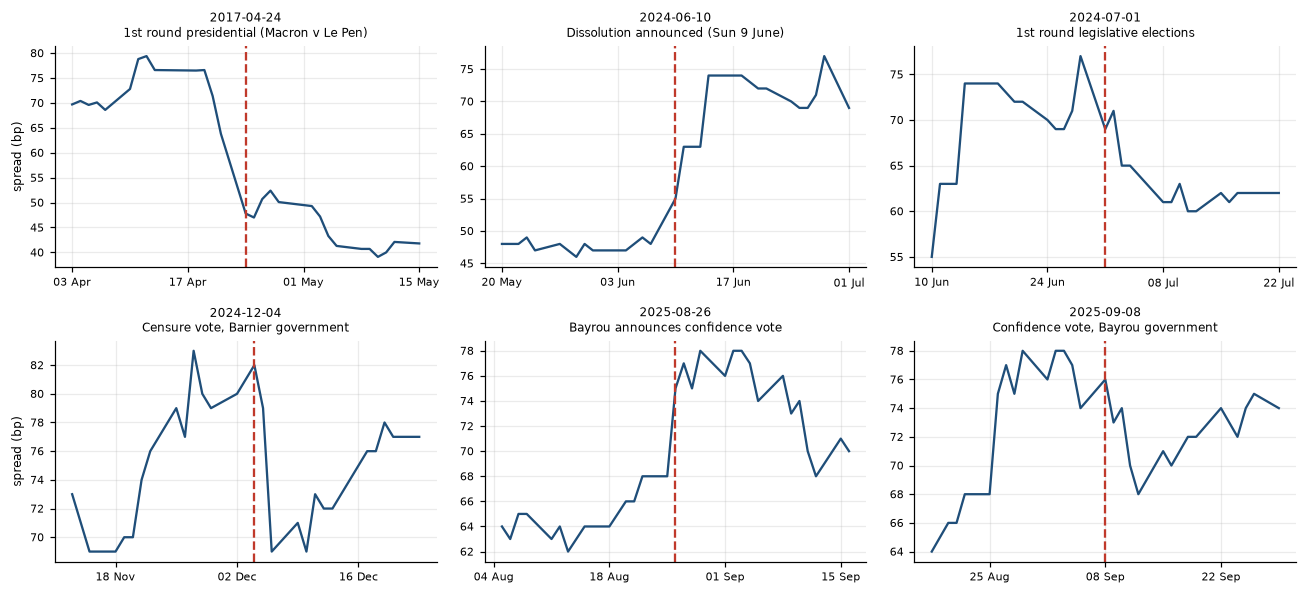

In [5]:
EVENTS = {"2017-04-24": "1st round presidential (Macron v Le Pen)", "2024-06-10": "Dissolution announced (Sun 9 June)",
          "2024-07-01": "1st round legislative elections", "2024-12-04": "Censure vote, Barnier government",
          "2025-08-26": "Bayrou announces confidence vote", "2025-09-08": "Confidence vote, Bayrou government"}
sp = daily["spread"]
chg2 = sp.diff(2)
rows = []
for d, lab in EVENTS.items():
    t = pd.Timestamp(d)
    if t not in sp.index: continue
    i = sp.index.get_loc(t)
    if i + 1 >= len(sp): continue
    move = sp.iloc[i + 1] - sp.iloc[i - 1]                         # day after minus day before
    ref = chg2.iloc[i - 270:i - 20].dropna()
    z = (move - ref.mean()) / ref.std()
    pct = (np.abs(ref) >= abs(move)).mean()
    rows.append({"date": d, "event": lab, "move_bp": round(move, 1), "z": round(z, 2), "two-sided empirical p": round(pct, 3)})
ev = pd.DataFrame(rows); ev.to_csv("data/out_04_event_study.csv", index=False); display(ev)

fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharey=False)
for ax, (d, lab) in zip(axes.ravel(), EVENTS.items()):
    t = pd.Timestamp(d); w = sp.loc[t - pd.Timedelta(days=21): t + pd.Timedelta(days=21)]
    ax.plot(w.index, w.values, color="#1f4e79"); ax.axvline(t, color="#c0392b", ls="--"); ax.set_title(f"{d}\n{lab}", fontsize=8); ax.tick_params(labelsize=7)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[0, 0].set_ylabel("spread (bp)", fontsize=8); axes[1, 0].set_ylabel("spread (bp)", fontsize=8)
plt.tight_layout(); plt.savefig("figures/04_events.png"); plt.show()

## 5. Local projections: response of the spread to an uncertainty innovation
Shock = residual of log-EPU regressed on 3 own lags and lags of the spread and VIX (the part of uncertainty that past information cannot predict). Response of spread(t+h) - spread(t-1), 1 s.d. shock, controls: lags of spread changes, VIX changes and of the shock. HAC bands (68% and 90%).
This is a *predictive* response: uncertainty and spreads react to the same news within the month, so it is not a causal effect.

Uncertainty innovation: n = 150 | R2 of the uncertainty model: 0.46


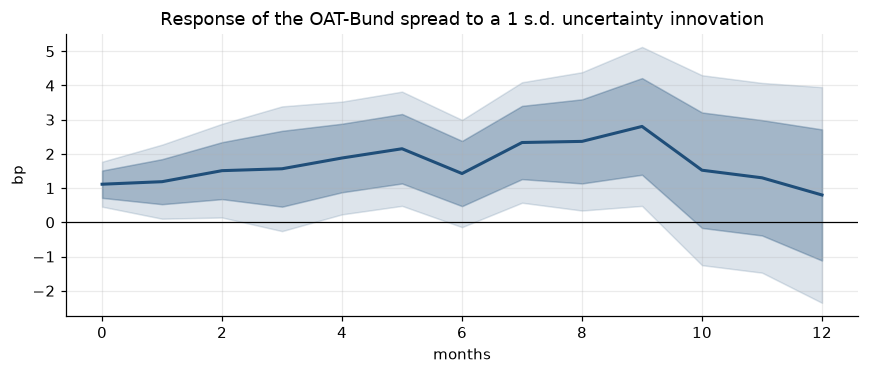

h,0,1,2,3,4,5,6,7,8,9,10,11,12
b,1.11,1.19,1.51,1.57,1.88,2.15,1.43,2.33,2.37,2.80,1.52,1.30,0.80
lo90,0.46,0.10,0.14,-0.26,0.23,0.48,-0.14,0.57,0.34,0.48,-1.25,-1.47,-2.35
hi90,1.77,2.27,2.88,3.39,3.53,3.82,2.99,4.09,4.39,5.13,4.30,4.07,3.95
lo68,0.71,0.53,0.68,0.46,0.88,1.14,0.47,1.26,1.14,1.39,-0.16,-0.39,-1.12
hi68,1.51,1.85,2.34,2.67,2.88,3.17,2.38,3.40,3.60,4.22,3.21,2.99,2.72


In [6]:
Z = pd.DataFrame({"lepu": M.lepu, "spread": M.spread, "vix": M.vix})
reg = pd.concat([Z.lepu] + [Z.lepu.shift(k).rename(f"lepu_l{k}") for k in (1, 2, 3)] + [Z.spread.shift(k).rename(f"sp_l{k}") for k in (1, 2, 3)] + [Z.vix.shift(k).rename(f"vix_l{k}") for k in (1, 2, 3)], axis=1).dropna()
shock = sm.OLS(reg.lepu, sm.add_constant(reg.drop(columns="lepu"))).fit().resid
shock = shock / shock.std()
print("Uncertainty innovation: n =", len(shock), "| R2 of the uncertainty model:", round(sm.OLS(reg.lepu, sm.add_constant(reg.drop(columns="lepu"))).fit().rsquared, 2))

H = 12; out = []
for h in range(H + 1):
    dep = M.spread.shift(-h) - M.spread.shift(1)
    C = pd.concat([dep.rename("dep"), shock.rename("shock")] + [shock.shift(k).rename(f"sh_l{k}") for k in (1, 2, 3)] +
                  [M.spread.diff().shift(k).rename(f"dsp_l{k}") for k in (1, 2, 3)] + [M.vix.diff().shift(k).rename(f"dvix_l{k}") for k in (0, 1, 2)], axis=1).dropna()
    m = sm.OLS(C.dep, sm.add_constant(C.drop(columns="dep"))).fit(cov_type="HAC", cov_kwds={"maxlags": max(h, 1) + 1})
    b, se = m.params["shock"], m.bse["shock"]
    out.append((h, b, b - 1.645 * se, b + 1.645 * se, b - se, b + se))
lp = pd.DataFrame(out, columns=["h", "b", "lo90", "hi90", "lo68", "hi68"]).set_index("h")
lp.to_csv("data/out_04_lp.csv")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(lp.index, lp.lo90, lp.hi90, color="#1f4e79", alpha=.15); ax.fill_between(lp.index, lp.lo68, lp.hi68, color="#1f4e79", alpha=.3)
ax.plot(lp.index, lp.b, color="#1f4e79", lw=2); ax.axhline(0, color="k", lw=.8); ax.set_xlabel("months"); ax.set_ylabel("bp")
ax.set_title("Response of the OAT-Bund spread to a 1 s.d. uncertainty innovation")
plt.tight_layout(); plt.savefig("figures/04_lp.png"); plt.show()
lp.round(2).T

## 6. Limits to keep in mind when reading
- The bounds test has low power on 150 monthly observations; a failure to reject is not proof of no long-run relation.
- Debt is a slow quarterly series; with 3-month publication lag it mostly captures a trend.
- Event windows contain other news; the percentile compares with ordinary days, not with other political shocks.
- The Italy spread controls for euro-area peripheral stress but also reacts to French news, which biases the French-specific effect toward zero.

**Extensions.** Add deficit forecasts (the variable markets price), rating-agency review dates, Spain as a second benchmark, and a regime-switching specification around the 2024 dissolution.